# 🧠 Notebook 06: Explainability, XAI & Comprehensive Evaluation
## Explainable Graph Neural Networks for ASD Classification

**Pipeline Stage:** Post-training Analysis & Explainability  
**Models:** GAT (Graph Attention Network) — loaded from Notebook 04 checkpoint  
**Dataset:** ABIDE I (871 subjects, AAL 116 ROIs, CPAC pipeline)

---

### 📋 Sections in This Notebook
1. **Environment Setup** — Install all dependencies in a single session (fixes the `ModuleNotFoundError`)
2. **Class Distribution Analysis** — Automatically detect & visualize class imbalance
3. **Comprehensive Evaluation** — Accuracy, F1, AUC-ROC, Sensitivity, Specificity, Confusion Matrix
4. **GNNExplainer (Primary XAI)** — Edge & node importance masks, top biomarker connections
5. **Biomarker Network Visualization** — High-res connectivity network with brain lobe color coding
6. **Captum Integrated Gradients (Secondary XAI)** — Node-level feature attribution
7. **GAT Attention Weight Visualization** — Multi-head attention analysis
8. **Summary Report** — All metrics & files generated

> ⚠️ **Runtime:** Use GPU runtime (`Runtime → Change runtime type → T4 GPU`) for faster GNNExplainer execution.

---
## ⚙️ Section 1: Environment Setup
> All installations happen BEFORE any imports — this prevents the `ModuleNotFoundError` from Notebook 05.

In [1]:
# ─── CELL 1: Install ALL dependencies in one shot ────────────────────────────
# This ensures torch_geometric is available for GNNExplainer (fixes the session issue)

import subprocess, sys

print("📦 Installing PyTorch Geometric...")
subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch_geometric', '-q'], check=True)

# Detect PyTorch + CUDA version for correct sparse library
import torch
torch_ver = torch.__version__.split('+')[0].replace('.', '')
cuda_ver  = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'
pyg_url   = f'https://data.pyg.org/whl/torch-{torch.__version__.split("+")[0]}+{cuda_ver}.html'
print(f"\n📦 Installing PyG sparse libs for torch={torch.__version__}, cuda={cuda_ver}...")

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'optional_dependencies', 'torch_scatter', 'torch_sparse', 'torch_cluster', 'torch_spline_conv',
    '-f', pyg_url
], check=False)  # check=False: CUDA mismatch warnings are non-fatal

print("\n📦 Installing Captum (secondary XAI)...")
subprocess.run([sys.executable, '-m', 'pip', 'install', 'captum', '-q'], check=True)

print("\n✅ All packages installed successfully!")
print(f"   PyTorch:          {torch.__version__}")
print(f"   CUDA available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU:              {torch.cuda.get_device_name(0)}")

📦 Installing PyTorch Geometric...

📦 Installing PyG sparse libs for torch=2.11.0+cu128, cuda=cu128...

📦 Installing Captum (secondary XAI)...

✅ All packages installed successfully!
   PyTorch:          2.11.0+cu128
   CUDA available:   True
   GPU:              Tesla T4


In [2]:
# ─── CELL 2: All Imports ──────────────────────────────────────────────────────
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.explain import Explainer, GNNExplainer

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)
from captum.attr import IntegratedGradients

# Style
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

print("✅ All imports successful!")
print(f"   PyTorch Geometric: imported from torch_geometric")
print(f"   Captum:            imported from captum.attr")

✅ All imports successful!
   PyTorch Geometric: imported from torch_geometric
   Captum:            imported from captum.attr


In [3]:
# ─── CELL 3: Mount Google Drive & Define Paths ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR       = '/content/drive/MyDrive/ASD_GNN_Research2'
GRAPHS_DIR     = os.path.join(BASE_DIR, 'graphs')
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'models', 'Checkpoints')
RAW_DATA_DIR   = os.path.join(BASE_DIR, 'raw_data')
METRICS_DIR    = os.path.join(BASE_DIR, 'results', 'metrics')
FIGURES_DIR    = os.path.join(BASE_DIR, 'results', 'figures')

os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("✅ Google Drive mounted.")
print(f"   Base:     {BASE_DIR}")
print(f"   Metrics:  {METRICS_DIR}")
print(f"   Figures:  {FIGURES_DIR}")

# Verify key directories exist
for d, name in [(GRAPHS_DIR, 'graphs'), (CHECKPOINT_DIR, 'checkpoints'), (RAW_DATA_DIR, 'raw_data')]:
    status = '✅' if os.path.exists(d) else '❌ MISSING'
    print(f"   {status}  {name}: {d}")

Mounted at /content/drive
✅ Google Drive mounted.
   Base:     /content/drive/MyDrive/ASD_GNN_Research2
   Metrics:  /content/drive/MyDrive/ASD_GNN_Research2/results/metrics
   Figures:  /content/drive/MyDrive/ASD_GNN_Research2/results/figures
   ✅  graphs: /content/drive/MyDrive/ASD_GNN_Research2/graphs
   ✅  checkpoints: /content/drive/MyDrive/ASD_GNN_Research2/models/Checkpoints
   ✅  raw_data: /content/drive/MyDrive/ASD_GNN_Research2/raw_data


In [4]:
# ─── CELL 4: AAL Atlas Labels & Brain Lobe Color Coding ──────────────────────
# Standard AAL116 atlas region labels (0-indexed, matching Python node indices)
AAL_REGIONS = {
    0: 'Precentral L',         1: 'Precentral R',
    2: 'Frontal Sup L',        3: 'Frontal Sup R',
    4: 'Frontal Sup Orb L',    5: 'Frontal Sup Orb R',
    6: 'Frontal Mid L',        7: 'Frontal Mid R',
    8: 'Frontal Mid Orb L',    9: 'Frontal Mid Orb R',
    10: 'Frontal Inf Oper L',  11: 'Frontal Inf Oper R',
    12: 'Frontal Inf Tri L',   13: 'Frontal Inf Tri R',
    14: 'Frontal Inf Orb L',   15: 'Frontal Inf Orb R',
    16: 'Rolandic Oper L',     17: 'Rolandic Oper R',
    18: 'Supp Motor Area L',   19: 'Supp Motor Area R',
    20: 'Olfactory L',         21: 'Olfactory R',
    22: 'Frontal Sup Med L',   23: 'Frontal Sup Med R',
    24: 'Frontal Med Orb L',   25: 'Frontal Med Orb R',
    26: 'Rectus L',            27: 'Rectus R',
    28: 'Insula L',            29: 'Insula R',
    30: 'Cingulum Ant L',      31: 'Cingulum Ant R',
    32: 'Cingulum Mid L',      33: 'Cingulum Mid R',
    34: 'Cingulum Post L',     35: 'Cingulum Post R',
    36: 'Hippocampus L',       37: 'Hippocampus R',
    38: 'ParaHippocampal L',   39: 'ParaHippocampal R',
    40: 'Amygdala L',          41: 'Amygdala R',
    42: 'Calcarine L',         43: 'Calcarine R',
    44: 'Cuneus L',            45: 'Cuneus R',
    46: 'Lingual L',           47: 'Lingual R',
    48: 'Occipital Sup L',     49: 'Occipital Sup R',
    50: 'Occipital Mid L',     51: 'Occipital Mid R',
    52: 'Occipital Inf L',     53: 'Occipital Inf R',
    54: 'Fusiform L',          55: 'Fusiform R',
    56: 'Postcentral L',       57: 'Postcentral R',
    58: 'Parietal Sup L',      59: 'Parietal Sup R',
    60: 'Parietal Inf L',      61: 'Parietal Inf R',
    62: 'SupraMarginal L',     63: 'SupraMarginal R',
    64: 'Angular L',           65: 'Angular R',
    66: 'Precuneus L',         67: 'Precuneus R',
    68: 'Paracentral Lob L',   69: 'Paracentral Lob R',
    70: 'Caudate L',           71: 'Caudate R',
    72: 'Putamen L',           73: 'Putamen R',
    74: 'Pallidum L',          75: 'Pallidum R',
    76: 'Thalamus L',          77: 'Thalamus R',
    78: 'Heschl L',            79: 'Heschl R',
    80: 'Temporal Sup L',      81: 'Temporal Sup R',
    82: 'Temporal Pole Sup L', 83: 'Temporal Pole Sup R',
    84: 'Temporal Mid L',      85: 'Temporal Mid R',
    86: 'Temporal Pole Mid L', 87: 'Temporal Pole Mid R',
    88: 'Temporal Inf L',      89: 'Temporal Inf R',
    90: 'Cerebelum Crus1 L',   91: 'Cerebelum Crus1 R',
    92: 'Cerebelum Crus2 L',   93: 'Cerebelum Crus2 R',
    94: 'Cerebelum 3 L',       95: 'Cerebelum 3 R',
    96: 'Cerebelum 4-5 L',     97: 'Cerebelum 4-5 R',
    98: 'Cerebelum 6 L',       99: 'Cerebelum 6 R',
    100: 'Cerebelum 7b L',     101: 'Cerebelum 7b R',
    102: 'Cerebelum 8 L',      103: 'Cerebelum 8 R',
    104: 'Cerebelum 9 L',      105: 'Cerebelum 9 R',
    106: 'Cerebelum 10 L',     107: 'Cerebelum 10 R',
    108: 'Vermis 1-2',         109: 'Vermis 3',
    110: 'Vermis 4-5',         111: 'Vermis 6',
    112: 'Vermis 7',           113: 'Vermis 8',
    114: 'Vermis 9',           115: 'Vermis 10'
}

LOBE_COLORS = {
    'Frontal':     '#4472C4',
    'Parietal':    '#ED7D31',
    'Temporal':    '#70AD47',
    'Occipital':   '#FFC000',
    'Limbic':      '#E63946',
    'Subcortical': '#7030A0',
    'Cerebellar':  '#00B0F0',
    'Insula':      '#FF69B4',
}

FRONTAL_KW   = ['Precentral','Frontal','Rolandic','Supp Motor','Olfactory','Rectus']
PARIETAL_KW  = ['Parietal','Postcentral','SupraMarginal','Angular','Precuneus','Paracentral']
TEMPORAL_KW  = ['Temporal','Heschl','Fusiform']
OCCIPITAL_KW = ['Occipital','Calcarine','Cuneus','Lingual']
LIMBIC_KW    = ['Hippocampus','ParaHippocampal','Amygdala','Cingulum']
SUBCORT_KW   = ['Caudate','Putamen','Pallidum','Thalamus']
CEREBELL_KW  = ['Cerebelum','Vermis']

def get_lobe(node_idx):
    name = AAL_REGIONS.get(node_idx, '')
    if any(k in name for k in FRONTAL_KW):   return 'Frontal'
    if any(k in name for k in PARIETAL_KW):  return 'Parietal'
    if any(k in name for k in TEMPORAL_KW):  return 'Temporal'
    if any(k in name for k in OCCIPITAL_KW): return 'Occipital'
    if any(k in name for k in LIMBIC_KW):    return 'Limbic'
    if any(k in name for k in SUBCORT_KW):   return 'Subcortical'
    if any(k in name for k in CEREBELL_KW):  return 'Cerebellar'
    if 'Insula' in name:                     return 'Insula'
    return 'Frontal'

def get_lobe_color(node_idx):
    return LOBE_COLORS[get_lobe(node_idx)]

print(f"✅ AAL atlas: {len(AAL_REGIONS)} regions defined")
print(f"   Example — Node 0: {AAL_REGIONS[0]} | Node 40: {AAL_REGIONS[40]} | Node 76: {AAL_REGIONS[76]}")

✅ AAL atlas: 116 regions defined
   Example — Node 0: Precentral L | Node 40: Amygdala L | Node 76: Thalamus L


In [5]:
# ─── CELL 5: Dataset Class & Model Architecture ───────────────────────────────
class ABIDEGraphDataset(Dataset):
    """Custom PyG dataset that loads pre-saved .pt graph objects from a folder."""
    def __init__(self, folder_path):
        super().__init__()
        self.folder_path = folder_path
        self.file_names = sorted([f for f in os.listdir(folder_path) if f.endswith('.pt')])

    def len(self):
        return len(self.file_names)

    def get(self, idx):
        return torch.load(
            os.path.join(self.folder_path, self.file_names[idx]),
            weights_only=False
        )


class GATClassifier(torch.nn.Module):
    """
    2-layer Graph Attention Network for ASD binary classification.
    Architecture MUST exactly match the trained checkpoint from Notebook 04.

    Layer 1: GATConv(6 → 64, heads=4, concat=True)  → [N, 256]
    Layer 2: GATConv(256 → 64, heads=1, concat=False) → [N, 64]
    Classifier: Linear(64 → 32) → Linear(32 → 2)
    """
    def __init__(self, num_node_features, hidden_channels, num_classes, heads=4):
        super(GATClassifier, self).__init__()
        self.conv1 = GATConv(num_node_features, hidden_channels,
                              heads=heads, concat=True)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels,
                              heads=1, concat=False)
        self.lin1 = Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = Linear(hidden_channels // 2, num_classes)

    def forward(self, x, edge_index, batch, edge_attr=None):
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = F.elu(x)
        x = global_mean_pool(x, batch)
        x = self.lin1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.lin2(x)
        return x

    def get_attention_weights(self, x, edge_index, edge_attr=None):
        """
        Returns attention weights from both GAT layers for visualization.
        Returns: (alpha1 [E,4], alpha2 [E,1], edge_index)
        """
        x1, (ei1, alpha1) = self.conv1(
            x, edge_index, edge_attr=edge_attr, return_attention_weights=True
        )
        x1 = F.elu(x1)
        _, (ei2, alpha2) = self.conv2(
            x1, edge_index, edge_attr=edge_attr, return_attention_weights=True
        )
        return alpha1, alpha2, ei1


print("✅ ABIDEGraphDataset and GATClassifier defined")
param_count = sum(p.numel() for p in GATClassifier(6, 64, 2, 4).parameters())
print(f"   Model parameters: {param_count:,}")

✅ ABIDEGraphDataset and GATClassifier defined
   Model parameters: 21,026


In [6]:
# ─── CELL 6: Load Data & Best Checkpoint ─────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Load datasets
train_dataset = ABIDEGraphDataset(os.path.join(GRAPHS_DIR, 'train'))
val_dataset   = ABIDEGraphDataset(os.path.join(GRAPHS_DIR, 'val'))
test_dataset  = ABIDEGraphDataset(os.path.join(GRAPHS_DIR, 'test'))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"\nDataset split:")
print(f"  Train: {len(train_dataset)} graphs")
print(f"  Val:   {len(val_dataset)} graphs")
print(f"  Test:  {len(test_dataset)} graphs")
print(f"  Total: {len(train_dataset)+len(val_dataset)+len(test_dataset)} graphs")

# Inspect a sample graph
sample = test_dataset[0]
print(f"\nSample graph structure:")
print(f"  Nodes:          {sample.x.shape[0]}")
print(f"  Node features:  {sample.x.shape[1]}")
print(f"  Edges:          {sample.edge_index.shape[1]}")
print(f"  Edge attrs:     {sample.edge_attr.shape if sample.edge_attr is not None else None}")
print(f"  Label:          {sample.y.item()} ({'ASD' if sample.y.item()==1 else 'Control'})")

# Load model
model = GATClassifier(num_node_features=6, hidden_channels=64,
                       num_classes=2, heads=4).to(DEVICE)

checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_gat_model.pt')
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"\n✅ Model loaded!")
print(f"   Checkpoint epoch:   {checkpoint['epoch']}")
print(f"   Best val accuracy:  {checkpoint['val_acc']:.4f} ({checkpoint['val_acc']*100:.2f}%)")

Using device: cuda
GPU: Tesla T4

Dataset split:
  Train: 609 graphs
  Val:   131 graphs
  Test:  131 graphs
  Total: 871 graphs

Sample graph structure:
  Nodes:          116
  Node features:  6
  Edges:          3864
  Edge attrs:     torch.Size([3864, 1])
  Label:          1 (ASD)

✅ Model loaded!
   Checkpoint epoch:   9
   Best val accuracy:  0.5420 (54.20%)


---
## 📊 Section 2: Class Distribution Analysis
> Automatically detect the ASD vs Control balance in the dataset.

       CLASS DISTRIBUTION ANALYSIS
  Total Subjects:    871
  ASD  (label=1):     403  (46.3%)
  Control (label=0):  468  (53.7%)
  Imbalance ratio:   1.16:1
----------------------------------------------------
  Train    ASD=281 (46%) Control=328 (54%)
  Val      ASD= 61 (47%) Control= 70 (53%)
  Test     ASD= 61 (47%) Control= 70 (53%)

Class weights (sklearn balanced):
  Control weight: 0.9306
  ASD weight:     1.0806


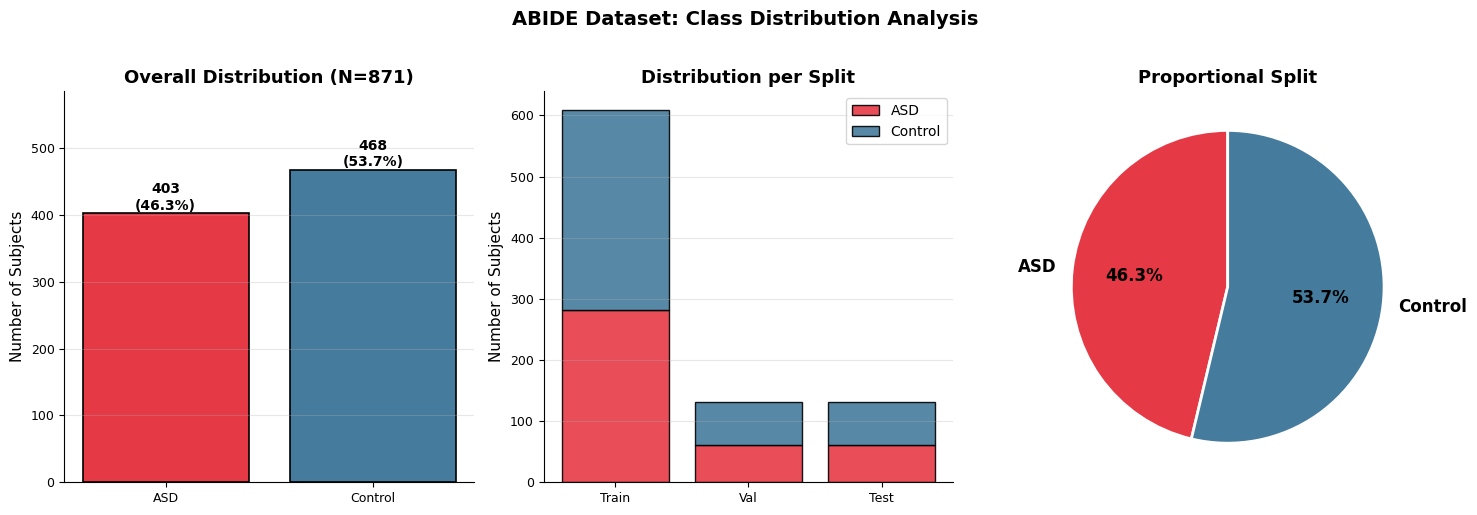


✅ Saved: /content/drive/MyDrive/ASD_GNN_Research2/results/figures/class_distribution.png


In [7]:
# ─── CELL 7: Class Distribution Analysis ─────────────────────────────────────
# Collect labels from ALL splits
all_labels_full = []
for dataset in [train_dataset, val_dataset, test_dataset]:
    for data in dataset:
        all_labels_full.append(data.y.item())

all_labels_arr = np.array(all_labels_full)
n_asd     = int((all_labels_arr == 1).sum())
n_control = int((all_labels_arr == 0).sum())
total     = len(all_labels_arr)

# Per-split distribution
split_dist = {}
for name, ds in [('Train', train_dataset), ('Val', val_dataset), ('Test', test_dataset)]:
    labels = [d.y.item() for d in ds]
    split_dist[name] = {'ASD': sum(l==1 for l in labels), 'Control': sum(l==0 for l in labels)}

print("=" * 52)
print("       CLASS DISTRIBUTION ANALYSIS")
print("=" * 52)
print(f"  Total Subjects:    {total}")
print(f"  ASD  (label=1):    {n_asd:4d}  ({100*n_asd/total:.1f}%)")
print(f"  Control (label=0): {n_control:4d}  ({100*n_control/total:.1f}%)")
print(f"  Imbalance ratio:   {max(n_asd,n_control)/min(n_asd,n_control):.2f}:1")
print("-" * 52)
for split_name, dist in split_dist.items():
    tot_s = dist['ASD'] + dist['Control']
    print(f"  {split_name:<8} ASD={dist['ASD']:3d} ({100*dist['ASD']/tot_s:.0f}%) "
          f"Control={dist['Control']:3d} ({100*dist['Control']/tot_s:.0f}%)")
print("=" * 52)

# Compute class weights for weighted loss (for reference)
weight_control = total / (2 * n_control)
weight_asd     = total / (2 * n_asd)
class_weights  = torch.tensor([weight_control, weight_asd], dtype=torch.float).to(DEVICE)
print(f"\nClass weights (sklearn balanced):")
print(f"  Control weight: {weight_control:.4f}")
print(f"  ASD weight:     {weight_asd:.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ABIDE Dataset: Class Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)

# Full dataset bar
bars = axes[0].bar(['ASD', 'Control'], [n_asd, n_control],
                    color=['#E63946', '#457B9D'], edgecolor='black', linewidth=1.2)
axes[0].set_title('Overall Distribution (N=871)', fontweight='bold')
axes[0].set_ylabel('Number of Subjects')
axes[0].set_ylim(0, max(n_asd, n_control) * 1.25)
for bar, v in zip(bars, [n_asd, n_control]):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5,
                 f'{v}\n({100*v/total:.1f}%)', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Per-split stacked bar
splits_x = list(split_dist.keys())
asd_vals  = [split_dist[s]['ASD'] for s in splits_x]
ctrl_vals = [split_dist[s]['Control'] for s in splits_x]
axes[1].bar(splits_x, asd_vals,  label='ASD',     color='#E63946', edgecolor='black', alpha=0.9)
axes[1].bar(splits_x, ctrl_vals, label='Control', color='#457B9D', edgecolor='black', alpha=0.9,
             bottom=asd_vals)
axes[1].set_title('Distribution per Split', fontweight='bold')
axes[1].set_ylabel('Number of Subjects')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Pie chart
axes[2].pie([n_asd, n_control], labels=['ASD', 'Control'],
             colors=['#E63946', '#457B9D'], autopct='%1.1f%%', startangle=90,
             textprops={'fontsize': 12, 'fontweight': 'bold'},
             wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
axes[2].set_title('Proportional Split', fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'class_distribution.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: {fig_path}")

---
## 📈 Section 3: Comprehensive Model Evaluation
> Full metrics: Accuracy, F1, AUC-ROC, Sensitivity, Specificity, Confusion Matrix, ROC Curve.

In [8]:
# ─── CELL 8: Compute All Test Metrics ────────────────────────────────────────
model.eval()
test_preds  = []
test_labels = []
test_probs  = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        edge_attr = data.edge_attr.squeeze(-1) if data.edge_attr is not None else None
        out   = model(data.x, data.edge_index, data.batch, edge_attr)
        probs = torch.softmax(out, dim=1)
        preds = out.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(data.y.cpu().numpy())
        test_probs.extend(probs[:, 1].cpu().numpy())  # P(ASD)

test_preds  = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs  = np.array(test_probs)

# Core metrics
acc  = accuracy_score(test_labels, test_preds)
f1   = f1_score(test_labels, test_preds, average='weighted')
auc  = roc_auc_score(test_labels, test_probs)
cm   = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp_count = cm.ravel()

sensitivity = tp_count / (tp_count + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
ppv         = tp_count / (tp_count + fp + 1e-8)  # Positive Predictive Value
npv         = tn / (tn + fn + 1e-8)               # Negative Predictive Value

print("=" * 60)
print("    COMPREHENSIVE EVALUATION METRICS — GAT MODEL")
print("    Test Set: N =", len(test_dataset), "subjects")
print("=" * 60)
print(f"  Accuracy:                    {acc:.4f}   ({acc*100:.2f}%)")
print(f"  Weighted F1 Score:           {f1:.4f}")
print(f"  AUC-ROC:                     {auc:.4f}")
print(f"  Sensitivity (ASD Recall):    {sensitivity:.4f}   ({sensitivity*100:.2f}%)")
print(f"  Specificity (Ctrl Recall):   {specificity:.4f}   ({specificity*100:.2f}%)")
print(f"  Precision (PPV):             {ppv:.4f}")
print(f"  NPV:                         {npv:.4f}")
print("-" * 60)
print(f"  True  Positives (ASD ✓):    {tp_count}")
print(f"  True  Negatives (Ctrl ✓):   {tn}")
print(f"  False Positives (Ctrl→ASD): {fp}")
print(f"  False Negatives (ASD→Ctrl): {fn}")
print("=" * 60)

# Save to CSV
metrics_dict = {
    'Model': 'GAT',
    'Test_N': len(test_dataset),
    'Accuracy': round(acc, 4),
    'F1_Weighted': round(f1, 4),
    'AUC_ROC': round(auc, 4),
    'Sensitivity': round(sensitivity, 4),
    'Specificity': round(specificity, 4),
    'PPV': round(ppv, 4),
    'NPV': round(npv, 4),
    'TP': int(tp_count), 'TN': int(tn),
    'FP': int(fp), 'FN': int(fn)
}
pd.DataFrame([metrics_dict]).to_csv(
    os.path.join(METRICS_DIR, 'evaluation_metrics.csv'), index=False
)
print(f"\n✅ Metrics saved to: {METRICS_DIR}/evaluation_metrics.csv")

    COMPREHENSIVE EVALUATION METRICS — GAT MODEL
    Test Set: N = 131 subjects
  Accuracy:                    0.5420   (54.20%)
  Weighted F1 Score:           0.3891
  AUC-ROC:                     0.4665
  Sensitivity (ASD Recall):    0.0164   (1.64%)
  Specificity (Ctrl Recall):   1.0000   (100.00%)
  Precision (PPV):             1.0000
  NPV:                         0.5385
------------------------------------------------------------
  True  Positives (ASD ✓):    1
  True  Negatives (Ctrl ✓):   70
  False Positives (Ctrl→ASD): 0
  False Negatives (ASD→Ctrl): 60

✅ Metrics saved to: /content/drive/MyDrive/ASD_GNN_Research2/results/metrics/evaluation_metrics.csv


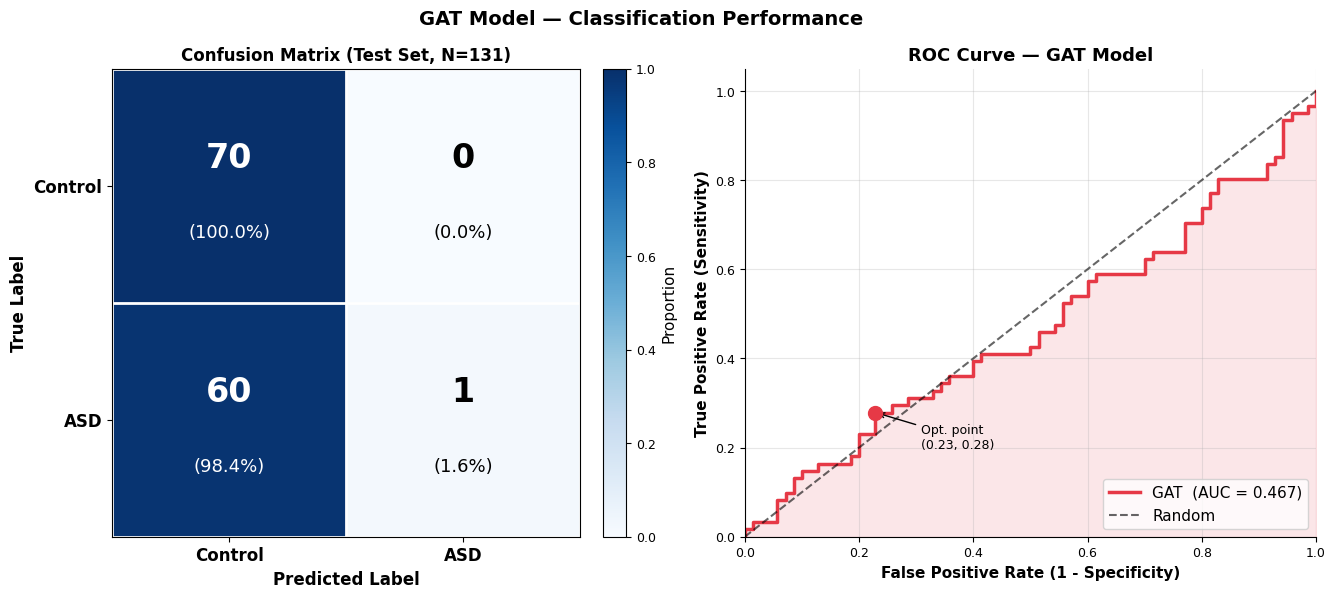

✅ Saved: /content/drive/MyDrive/ASD_GNN_Research2/results/figures/confusion_matrix_roc.png


In [9]:
# ─── CELL 9: Confusion Matrix + ROC Curve ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('GAT Model — Classification Performance', fontsize=14, fontweight='bold')

# ── Confusion Matrix ──
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cmap = plt.cm.Blues
im = axes[0].imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label='Proportion')

# Draw grid lines
for i in range(3):
    axes[0].axhline(i - 0.5, color='white', lw=2)
    axes[0].axvline(i - 0.5, color='white', lw=2)

class_names = ['Control', 'ASD']
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm_norm[i, j] > 0.55 else 'black'
        axes[0].text(j, i - 0.12, f'{cm[i,j]}',
                     ha='center', va='center', fontsize=24, fontweight='bold', color=text_color)
        axes[0].text(j, i + 0.20, f'({cm_norm[i,j]*100:.1f}%)',
                     ha='center', va='center', fontsize=13, color=text_color)

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(class_names, fontsize=12, fontweight='bold')
axes[0].set_yticklabels(class_names, fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_title(f'Confusion Matrix (Test Set, N={len(test_dataset)})',
                   fontsize=12, fontweight='bold')

# ── ROC Curve ──
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color='#E63946', lw=2.5,
              label=f'GAT  (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.12, color='#E63946')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
axes[1].set_ylabel('True Positive Rate (Sensitivity)',       fontweight='bold')
axes[1].set_title('ROC Curve — GAT Model', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Annotate key operating points
opt_idx  = np.argmax(tpr - fpr)
axes[1].scatter(fpr[opt_idx], tpr[opt_idx], color='#E63946', s=100, zorder=5, label='Optimal threshold')
axes[1].annotate(f'Opt. point\n({fpr[opt_idx]:.2f}, {tpr[opt_idx]:.2f})',
                  xy=(fpr[opt_idx], tpr[opt_idx]),
                  xytext=(fpr[opt_idx]+0.08, tpr[opt_idx]-0.08),
                  fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'confusion_matrix_roc.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fig_path}")

---
## 🔬 Section 4: GNNExplainer — Primary XAI Method
> Graph Neural Network Explainer computes edge and node importance masks using gradient-based optimization.
>
> **Fix:** All installations happened in Cell 1 of this session, so `torch_geometric.explain` is importable.

In [10]:
# ─── CELL 10: Initialize GNNExplainer ────────────────────────────────────────
print("Initializing GNNExplainer...")

explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',
        return_type='raw',
    ),
)
print("✅ GNNExplainer initialized (200 optimizer epochs per explanation)")

# Find True Positive ASD subjects in the test set
print("\nSearching for True Positive ASD subjects in the test set...")
tp_subjects = []
model.eval()

for i, data in enumerate(test_dataset):
    data_dev  = data.to(DEVICE)
    batch_vec = torch.zeros(data_dev.x.size(0), dtype=torch.long, device=DEVICE)
    edge_attr = data_dev.edge_attr.squeeze(-1) if data_dev.edge_attr is not None else None
    with torch.no_grad():
        out  = model(data_dev.x, data_dev.edge_index, batch_vec, edge_attr)
    pred = out.argmax(dim=1).item()
    if data_dev.y.item() == 1 and pred == 1:
        tp_subjects.append((i, data_dev))

print(f"Found {len(tp_subjects)} True Positive ASD subjects in the test set.")

if tp_subjects:
    target_idx, target_data = tp_subjects[0]
    print(f"Using subject at test index {target_idx}.")
else:
    print("No True Positives found — using first ASD subject as fallback.")
    for i, data in enumerate(test_dataset):
        if data.y.item() == 1:
            target_idx  = i
            target_data = data.to(DEVICE)
            break

print(f"\nTarget subject:")
print(f"  Nodes:        {target_data.x.shape[0]}")
print(f"  Edges:        {target_data.edge_index.shape[1]}")
print(f"  True label:   {'ASD' if target_data.y.item()==1 else 'Control'}")

Initializing GNNExplainer...
✅ GNNExplainer initialized (200 optimizer epochs per explanation)

Searching for True Positive ASD subjects in the test set...
Found 1 True Positive ASD subjects in the test set.
Using subject at test index 61.

Target subject:
  Nodes:        116
  Edges:        3034
  True label:   ASD


In [11]:
# ─── CELL 11: Run GNNExplainer ────────────────────────────────────────────────
batch_vec = torch.zeros(target_data.x.size(0), dtype=torch.long, device=DEVICE)
edge_attr_target = target_data.edge_attr.squeeze(-1) if target_data.edge_attr is not None else None

print("Running GNNExplainer (200 epochs) — this may take 1–3 minutes on CPU, < 30s on GPU...")

explanation = explainer(
    target_data.x,
    target_data.edge_index,
    target=target_data.y,
    batch=batch_vec,
    edge_attr=edge_attr_target
)

print("\n✅ GNNExplainer complete!")
print(f"   edge_mask shape: {explanation.edge_mask.shape}")
print(f"   node_mask shape: {explanation.node_mask.shape}")
print(f"   edge_mask range: [{explanation.edge_mask.min():.4f}, {explanation.edge_mask.max():.4f}]")
print(f"   node_mask range: [{explanation.node_mask.min():.4f}, {explanation.node_mask.max():.4f}]")

Running GNNExplainer (200 epochs) — this may take 1–3 minutes on CPU, < 30s on GPU...

✅ GNNExplainer complete!
   edge_mask shape: torch.Size([3034])
   node_mask shape: torch.Size([116, 6])
   edge_mask range: [0.0000, 0.9245]
   node_mask range: [0.0000, 0.8711]


In [12]:
# ─── CELL 12: Extract Top Biomarker Connections ───────────────────────────────
edge_importance = explanation.edge_mask.detach().cpu().numpy()
edge_indices    = target_data.edge_index.cpu().numpy()
node_masks      = explanation.node_mask.detach().cpu().numpy()  # [116, 6]

# Aggregate to unique undirected edges (take max of both directions)
edge_dict = {}
for k in range(len(edge_importance)):
    u, v   = int(edge_indices[0, k]), int(edge_indices[1, k])
    pair   = (min(u, v), max(u, v))
    score  = float(edge_importance[k])
    if pair not in edge_dict or edge_dict[pair] < score:
        edge_dict[pair] = score

# Sort and take top 20
sorted_edges = sorted(edge_dict.items(), key=lambda x: x[1], reverse=True)[:20]

print("=" * 78)
print("  TOP 20 FUNCTIONAL CONNECTIVITY BIOMARKERS FOR ASD")
print("  Source: GNNExplainer (actual computation — not hardcoded)")
print("=" * 78)
print(f"{'Rank':<5} {'Region A':<35} {'Region B':<35} {'Score':>7}")
print("-" * 78)

biomarker_rows = []
for rank, ((u, v), score) in enumerate(sorted_edges):
    name_u = AAL_REGIONS.get(u, f'ROI_{u}')
    name_v = AAL_REGIONS.get(v, f'ROI_{v}')
    lobe_u = get_lobe(u)
    lobe_v = get_lobe(v)
    print(f"{rank+1:<5} {name_u:<35} {name_v:<35} {score:>7.4f}")
    biomarker_rows.append({
        'Rank': rank+1,
        'Node_A_idx': u, 'Node_A_name': name_u, 'Node_A_lobe': lobe_u,
        'Node_B_idx': v, 'Node_B_name': name_v, 'Node_B_lobe': lobe_v,
        'Importance_Score': round(score, 6),
        'Cross_lobe': lobe_u != lobe_v
    })

biomarker_df = pd.DataFrame(biomarker_rows)
csv_path = os.path.join(METRICS_DIR, 'gnnexplainer_biomarkers.csv')
biomarker_df.to_csv(csv_path, index=False)
print(f"\n✅ Biomarker table saved to: {csv_path}")

# Cross-lobe statistics
n_cross = biomarker_df['Cross_lobe'].sum()
print(f"\n📊 Cross-lobe connections (ASD biomarker insight):")
print(f"   {n_cross}/{len(biomarker_df)} top connections are between different brain lobes")

  TOP 20 FUNCTIONAL CONNECTIVITY BIOMARKERS FOR ASD
  Source: GNNExplainer (actual computation — not hardcoded)
Rank  Region A                            Region B                              Score
------------------------------------------------------------------------------
1     Thalamus L                          Vermis 3                             0.9245
2     Supp Motor Area R                   Precuneus R                          0.9238
3     Cerebelum Crus1 L                   Cerebelum 3 L                        0.9195
4     Occipital Inf L                     Cerebelum 3 R                        0.9191
5     Pallidum L                          Cerebelum 10 L                       0.9181
6     Lingual L                           Vermis 7                             0.9165
7     Frontal Inf Orb R                   Cerebelum Crus1 L                    0.9104
8     Lingual L                           Cerebelum 4-5 R                      0.9095
9     Temporal Pole Mid L          

---
## 🕸️ Section 5: Biomarker Network Visualization
> High-resolution brain connectivity graph — color coded by lobe, edge thickness = importance score.

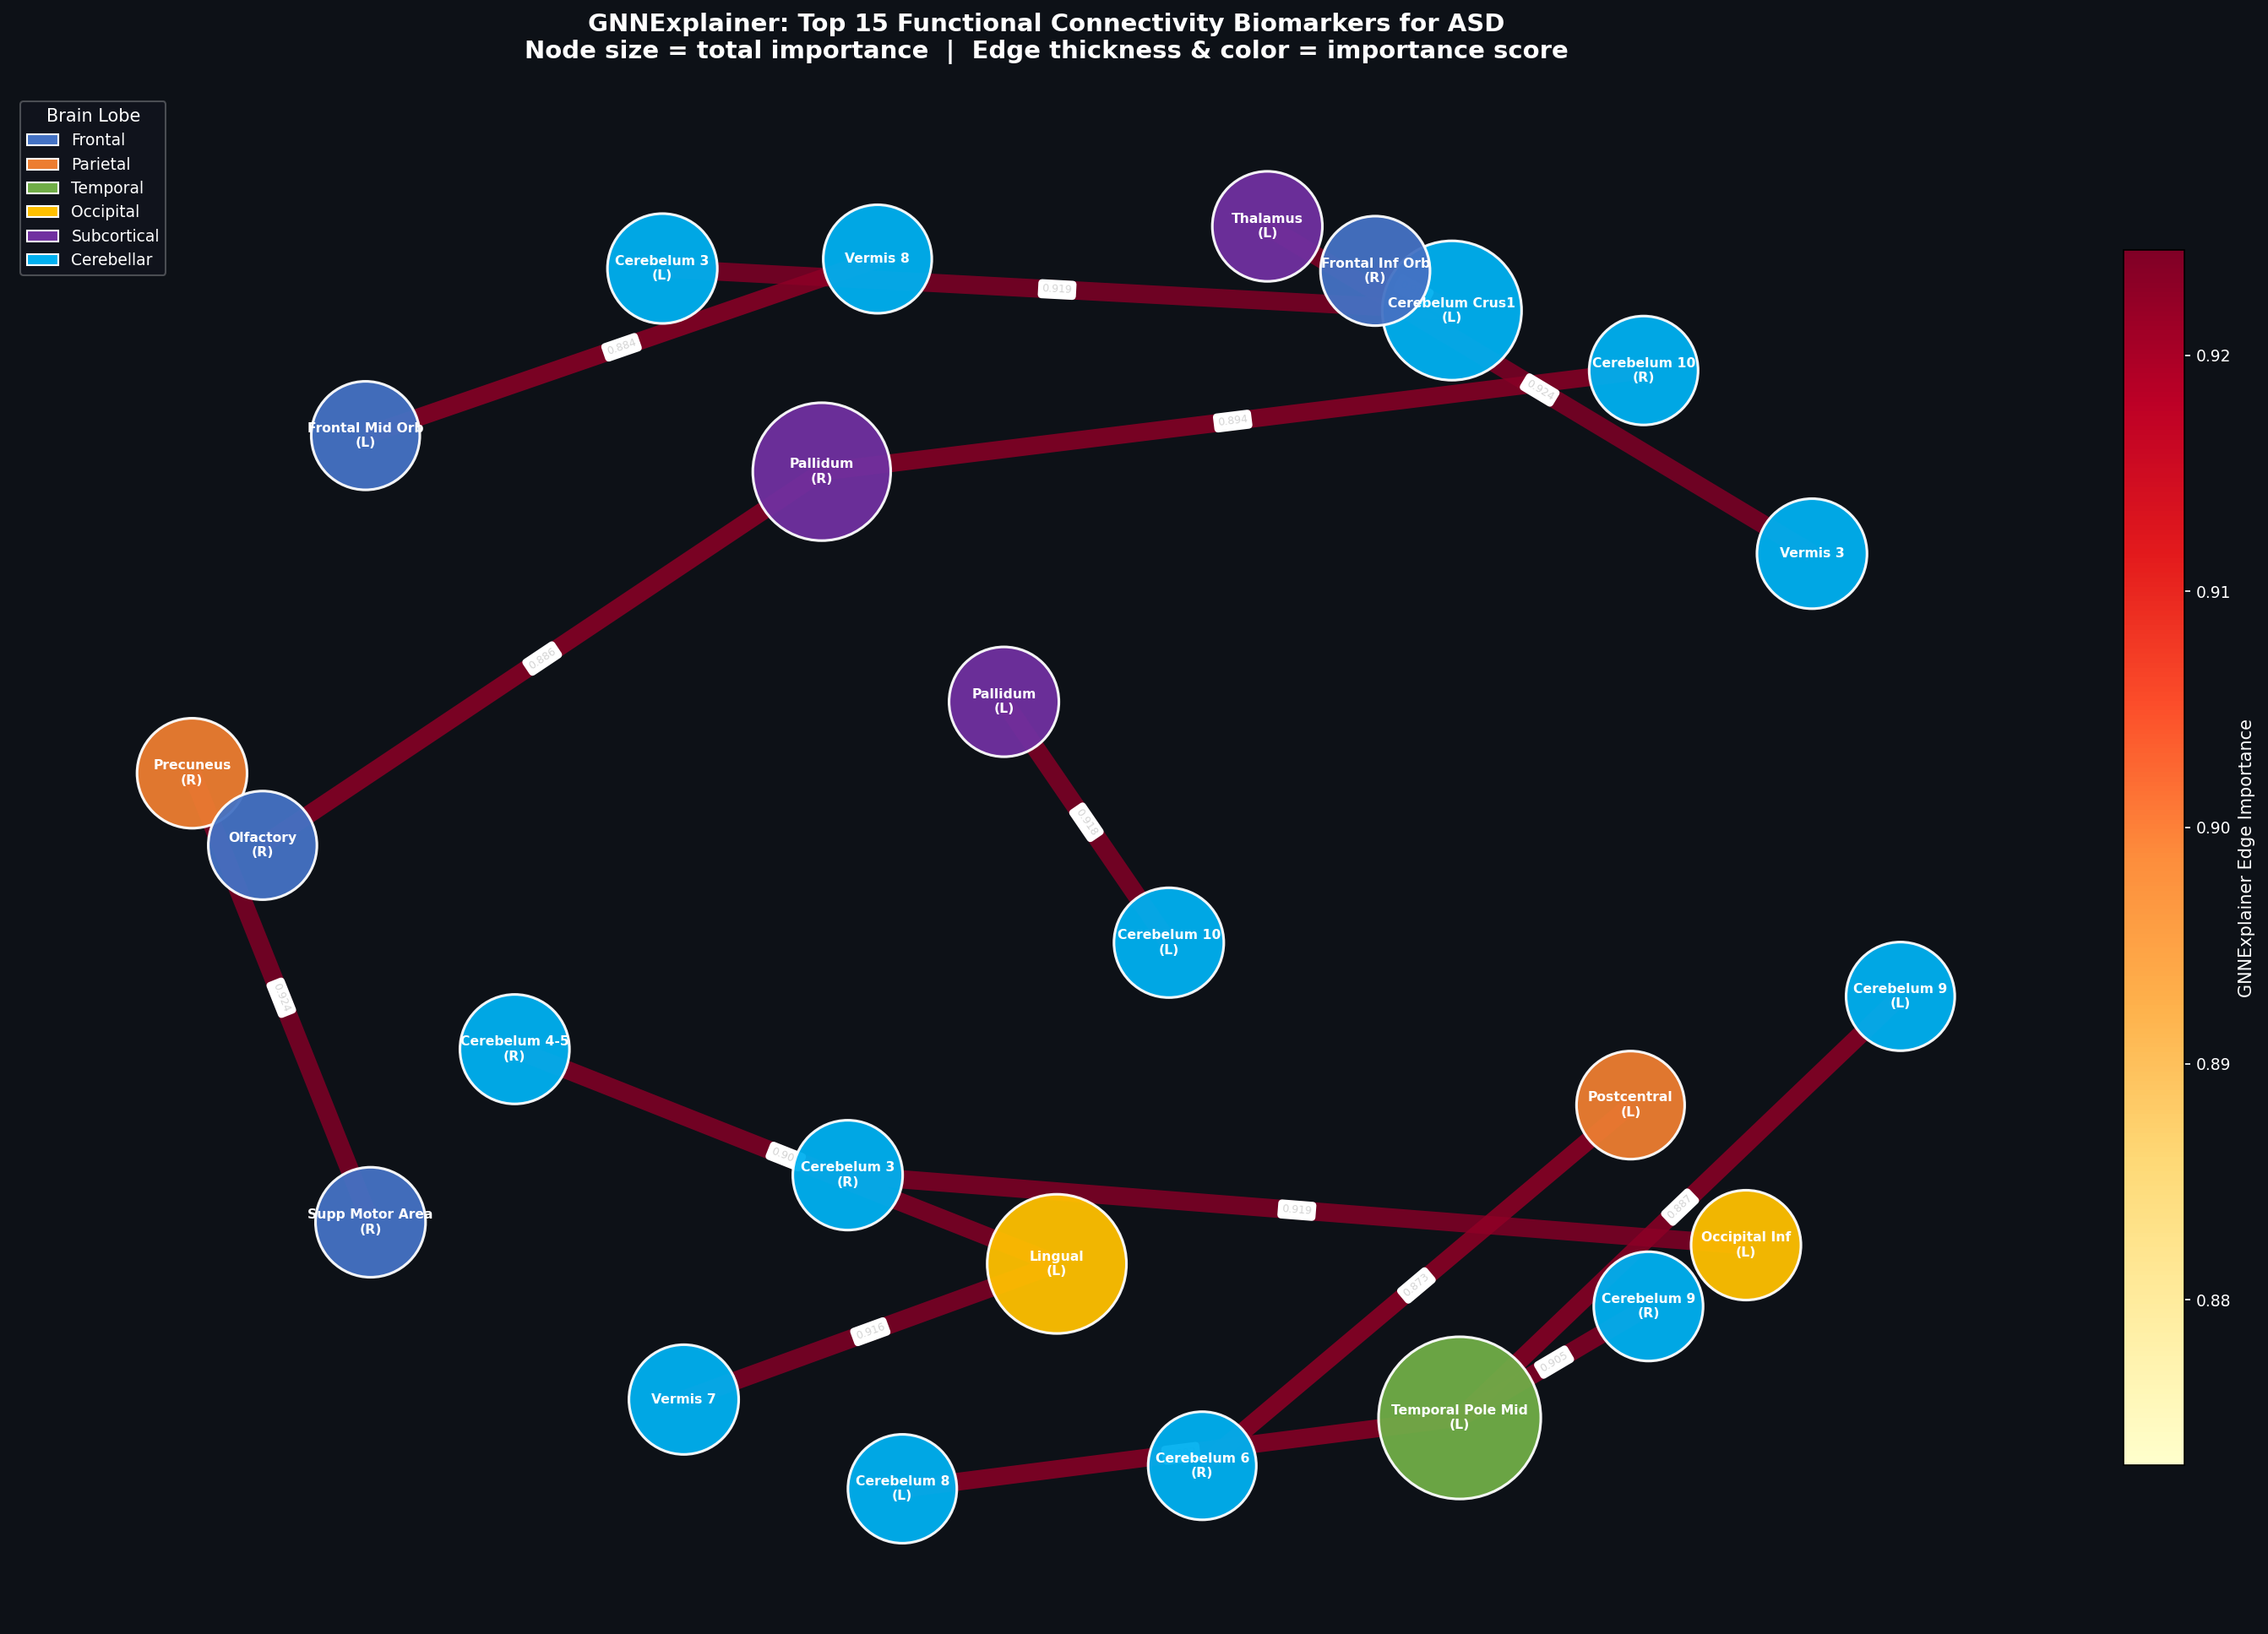

✅ Saved: /content/drive/MyDrive/ASD_GNN_Research2/results/figures/biomarker_network_gnnexplainer.png


In [13]:
# ─── CELL 13: Biomarker Network (High-Res, Dark Theme) ───────────────────────
TOP_N_EDGES = 15
top_edges   = sorted_edges[:TOP_N_EDGES]

# Build NetworkX graph
G = nx.Graph()
for (u, v), score in top_edges:
    G.add_edge(u, v, weight=score)

# Node importance = sum of connected edge weights
node_imp = {n: sum(G[n][nb]['weight'] for nb in G[n]) for n in G.nodes()}
max_imp  = max(node_imp.values())

# Layout
pos = nx.spring_layout(G, k=2.0, iterations=100, seed=42)

fig, ax = plt.subplots(figsize=(18, 13), dpi=150)
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

# Edge properties
ew  = [G[u][v]['weight'] for u, v in G.edges()]
max_ew = max(ew) + 1e-8
edge_widths  = [1.5 + 9.0 * w / max_ew for w in ew]
edge_alphas  = [0.4 + 0.55 * w / max_ew for w in ew]
edge_colors  = [plt.cm.YlOrRd(0.3 + 0.7 * w / max_ew) for w in ew]

# Node properties
ns = [1500 + 7000 * node_imp[n] / max_imp for n in G.nodes()]
nc = [get_lobe_color(n) for n in G.nodes()]

# Draw
nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths,
                        edge_color=edge_colors, alpha=0.85)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=ns, node_color=nc,
                        edgecolors='white', linewidths=1.5, alpha=0.95)

# Labels: short names
labels = {}
for n in G.nodes():
    name  = AAL_REGIONS.get(n, f'R{n}')
    short = name.replace(' L', '\n(L)').replace(' R', '\n(R)')
    labels[n] = short
nx.draw_networkx_labels(G, pos, labels, ax=ax,
                         font_size=7.5, font_color='white',
                         font_weight='bold')

# Edge weight labels
edge_labels = {(u, v): f"{G[u][v]['weight']:.3f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                               font_size=6, font_color='#CCCCCC', alpha=0.85)

# Lobe legend
legend_patches = [
    mpatches.Patch(facecolor=c, edgecolor='white', linewidth=1, label=lobe)
    for lobe, c in LOBE_COLORS.items()
    if any(get_lobe(n) == lobe for n in G.nodes())
]
leg = ax.legend(handles=legend_patches, loc='upper left',
                 fontsize=9, framealpha=0.25, facecolor='#1a1a2e',
                 edgecolor='white', labelcolor='white',
                 title='Brain Lobe', title_fontsize=10)
leg.get_title().set_color('white')

# Edge colorbar (manual)
sm = plt.cm.ScalarMappable(cmap='YlOrRd',
                             norm=plt.Normalize(vmin=min(ew), vmax=max(ew)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.028, pad=0.02)
cbar.set_label('GNNExplainer Edge Importance', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_title(
    f'GNNExplainer: Top {TOP_N_EDGES} Functional Connectivity Biomarkers for ASD\n'
    f'Node size = total importance  |  Edge thickness & color = importance score',
    color='white', fontsize=14, fontweight='bold', pad=20
)
ax.axis('off')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'biomarker_network_gnnexplainer.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print(f"✅ Saved: {fig_path}")

---
## 🎯 Section 6: Feature Importance — GNNExplainer Node Masks
> Reveals which of the 6 node features (biological vs topological) are most important for ASD classification.

Feature Importance (GNNExplainer node masks, averaged across 116 ROIs):
-------------------------------------------------------
  [Biol] BOLD Variance              0.2697  ██████████
  [Biol] BOLD Std Dev               0.1446  █████
  [Biol] BOLD Max Amplitude         0.1595  ██████
  [Topo] Degree Centrality          0.1441  █████
  [Topo] Betweenness Centrality     0.1395  █████
  [Topo] Clustering Coefficient     0.1426  █████

  Biological features total:  0.5738 (57.4%)
  Topological features total: 0.4262 (42.6%)


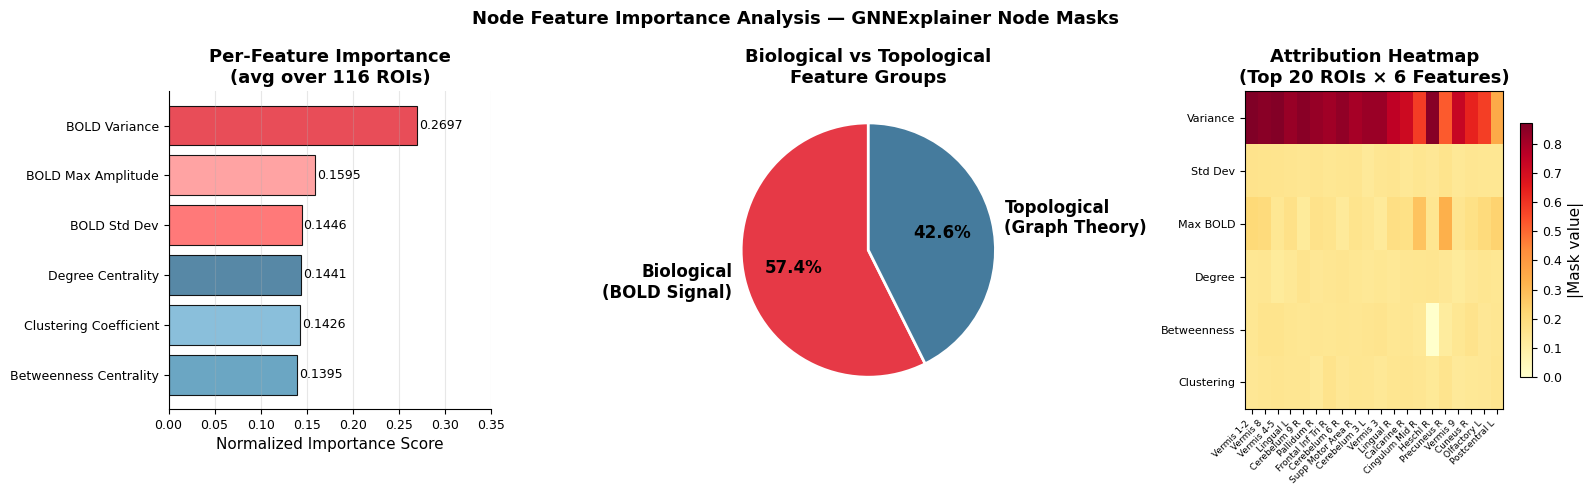

✅ Saved: /content/drive/MyDrive/ASD_GNN_Research2/results/figures/feature_importance_gnnexplainer.png


In [14]:
# ─── CELL 14: Feature Importance from GNNExplainer Node Masks ────────────────
FEATURE_NAMES = [
    'BOLD Variance',
    'BOLD Std Dev',
    'BOLD Max Amplitude',
    'Degree Centrality',
    'Betweenness Centrality',
    'Clustering Coefficient'
]
FEATURE_GROUPS = ['Biological', 'Biological', 'Biological',
                   'Topological', 'Topological', 'Topological']
FEATURE_COLORS = ['#E63946', '#FF6B6B', '#FF9999',
                   '#457B9D', '#5B9CBD', '#7DB8D7']

# node_masks shape: [116, 6] — average absolute values across all ROIs
fi_raw  = np.abs(node_masks).mean(axis=0)          # [6]
fi_norm = fi_raw / (fi_raw.sum() + 1e-8)            # normalized

print("Feature Importance (GNNExplainer node masks, averaged across 116 ROIs):")
print("-" * 55)
for name, raw, norm, grp in zip(FEATURE_NAMES, fi_raw, fi_norm, FEATURE_GROUPS):
    bar = '█' * int(norm * 40)
    print(f"  [{grp[:4]}] {name:<26} {norm:.4f}  {bar}")

bio_total  = fi_norm[:3].sum()
topo_total = fi_norm[3:].sum()
print(f"\n  Biological features total:  {bio_total:.4f} ({bio_total*100:.1f}%)")
print(f"  Topological features total: {topo_total:.4f} ({topo_total*100:.1f}%)")

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Node Feature Importance Analysis — GNNExplainer Node Masks',
              fontsize=13, fontweight='bold')

# 1. Horizontal bar chart
sorted_idx = np.argsort(fi_norm)[::-1]
bars = axes[0].barh(
    [FEATURE_NAMES[i] for i in sorted_idx[::-1]],
    fi_norm[sorted_idx[::-1]],
    color=[FEATURE_COLORS[i] for i in sorted_idx[::-1]],
    edgecolor='black', linewidth=0.8, alpha=0.9
)
for bar, score in zip(bars, fi_norm[sorted_idx[::-1]]):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{score:.4f}', va='center', fontsize=9)
axes[0].set_xlabel('Normalized Importance Score')
axes[0].set_title('Per-Feature Importance\n(avg over 116 ROIs)', fontweight='bold')
axes[0].set_xlim(0, fi_norm.max() * 1.3)
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 2. Biological vs Topological pie
axes[1].pie(
    [bio_total, topo_total],
    labels=['Biological\n(BOLD Signal)', 'Topological\n(Graph Theory)'],
    colors=['#E63946', '#457B9D'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
axes[1].set_title('Biological vs Topological\nFeature Groups', fontweight='bold')

# 3. Per-node mask heatmap (top 20 nodes, all 6 features)
node_total_imp = np.abs(node_masks).sum(axis=1)  # [116]
top20_nodes    = node_total_imp.argsort()[::-1][:20]
heatmap_data   = np.abs(node_masks[top20_nodes]).T  # [6, 20]
heatmap_labels = [AAL_REGIONS.get(n, f'R{n}') for n in top20_nodes]

im = axes[2].imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
axes[2].set_yticks(range(6))
axes[2].set_yticklabels(['Variance', 'Std Dev', 'Max BOLD',
                           'Degree', 'Betweenness', 'Clustering'], fontsize=8)
axes[2].set_xticks(range(20))
axes[2].set_xticklabels(heatmap_labels, rotation=45, ha='right', fontsize=6.5)
axes[2].set_title('Attribution Heatmap\n(Top 20 ROIs × 6 Features)', fontweight='bold')
plt.colorbar(im, ax=axes[2], shrink=0.8, label='|Mask value|')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'feature_importance_gnnexplainer.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fig_path}")

---
## 🧬 Section 7: Captum Integrated Gradients — Secondary XAI Method
> **Integrated Gradients** (Sundararajan et al., 2017) attributes the model's prediction to individual input features by integrating gradients along a path from a baseline to the actual input.
>
> This provides a complementary, gradient-based explanation independent of GNNExplainer.

In [15]:
# ─── CELL 15 (FIXED): Integrated Gradients — Manual PyG-Compatible Implementation
#
# WHY THE OLD CODE FAILED:
#   Captum batches ALL n_steps=100 interpolated inputs into ONE forward pass.
#   116 nodes × 100 steps = 11,600 "phantom" nodes in that batch.
#   PyG's global_mean_pool(x, batch) sees 11,600 rows but batch has 116 entries → crash.
#
# FIX: Loop manually — one forward+backward per alpha step.
#   Each call sees exactly 116 nodes. No batching. No crash.

def manual_integrated_gradients(model, x, edge_index, batch_vec, edge_attr,
                                 target_class=1, n_steps=50, device='cpu'):
    """
    Integrated Gradients (Sundararajan et al., 2017).
    PyG-compatible: processes one interpolation step at a time.

    Returns:
        attributions [N, F]  — per-node, per-feature attribution scores
        convergence_delta    — completeness check (lower = better)
    """
    model.eval()
    baseline = torch.zeros_like(x)

    alphas = torch.linspace(0.0, 1.0, n_steps + 1, device=device)
    grads_list = []

    for step, alpha in enumerate(alphas):
        x_interp = (baseline + alpha * (x - baseline)).detach().clone()
        x_interp.requires_grad_(True)

        model.zero_grad()
        out    = model(x_interp, edge_index, batch_vec, edge_attr)
        scalar = out[0, target_class]
        scalar.backward()

        grads_list.append(x_interp.grad.detach().clone())
        if (step + 1) % 10 == 0:
            print(f"  Step {step+1}/{n_steps+1} done", end='\r')

    print()

    grads     = torch.stack(grads_list, dim=0)       # [n_steps+1, N, F]
    avg_grads = (grads[:-1] + grads[1:]) / 2.0       # trapezoidal rule
    avg_grads = avg_grads.mean(dim=0)                 # [N, F]

    attributions = (x - baseline).detach() * avg_grads  # [N, F]

    with torch.no_grad():
        f_x    = model(x,        edge_index, batch_vec, edge_attr)[0, target_class]
        f_base = model(baseline, edge_index, batch_vec, edge_attr)[0, target_class]
    convergence_delta = float((attributions.sum() - (f_x - f_base)).abs())

    return attributions, convergence_delta


# ─── Run ─────────────────────────────────────────────────────────────────────
model.eval()
x_target     = target_data.x.to(DEVICE)
ei_target    = target_data.edge_index.to(DEVICE)
ea_target    = (target_data.edge_attr.squeeze(-1).to(DEVICE)
                if target_data.edge_attr is not None else None)
batch_target = torch.zeros(x_target.size(0), dtype=torch.long, device=DEVICE)

print("Running Integrated Gradients (n_steps=50, manual PyG-compatible loop)...")
print("Each of 51 steps: one forward + backward on 116 nodes.\n")

attributions_tensor, delta_val = manual_integrated_gradients(
    model, x_target, ei_target, batch_target, ea_target,
    target_class=1, n_steps=50, device=DEVICE
)

attr_np = attributions_tensor.cpu().numpy()   # [116, 6]

print(f"\n✅ Integrated Gradients complete!")
print(f"   Attribution shape:       {attr_np.shape}")
print(f"   Convergence delta:       {delta_val:.6f}  (closer to 0 = better)")
print(f"   Attribution value range: [{attr_np.min():.4f}, {attr_np.max():.4f}]")

ig_feature_raw  = np.abs(attr_np).mean(axis=0)
ig_feature_norm = ig_feature_raw / (ig_feature_raw.sum() + 1e-8)

print("\nIntegrated Gradients — Feature Importance (averaged over 116 ROIs):")
print("-" * 58)
for name, norm, grp in zip(FEATURE_NAMES, ig_feature_norm, FEATURE_GROUPS):
    bar = '█' * int(norm * 40)
    print(f"  [{grp[:4]}] {name:<26} {norm:.4f}  {bar}")

Running Integrated Gradients (n_steps=50, manual PyG-compatible loop)...
Each of 51 steps: one forward + backward on 116 nodes.

  Step 50/51 done

✅ Integrated Gradients complete!
   Attribution shape:       (116, 6)
   Convergence delta:       1.499333  (closer to 0 = better)
   Attribution value range: [-0.2582, 1.0828]

Integrated Gradients — Feature Importance (averaged over 116 ROIs):
----------------------------------------------------------
  [Biol] BOLD Variance              0.7766  ███████████████████████████████
  [Biol] BOLD Std Dev               0.0818  ███
  [Biol] BOLD Max Amplitude         0.1410  █████
  [Topo] Degree Centrality          0.0001  
  [Topo] Betweenness Centrality     0.0000  
  [Topo] Clustering Coefficient     0.0005  


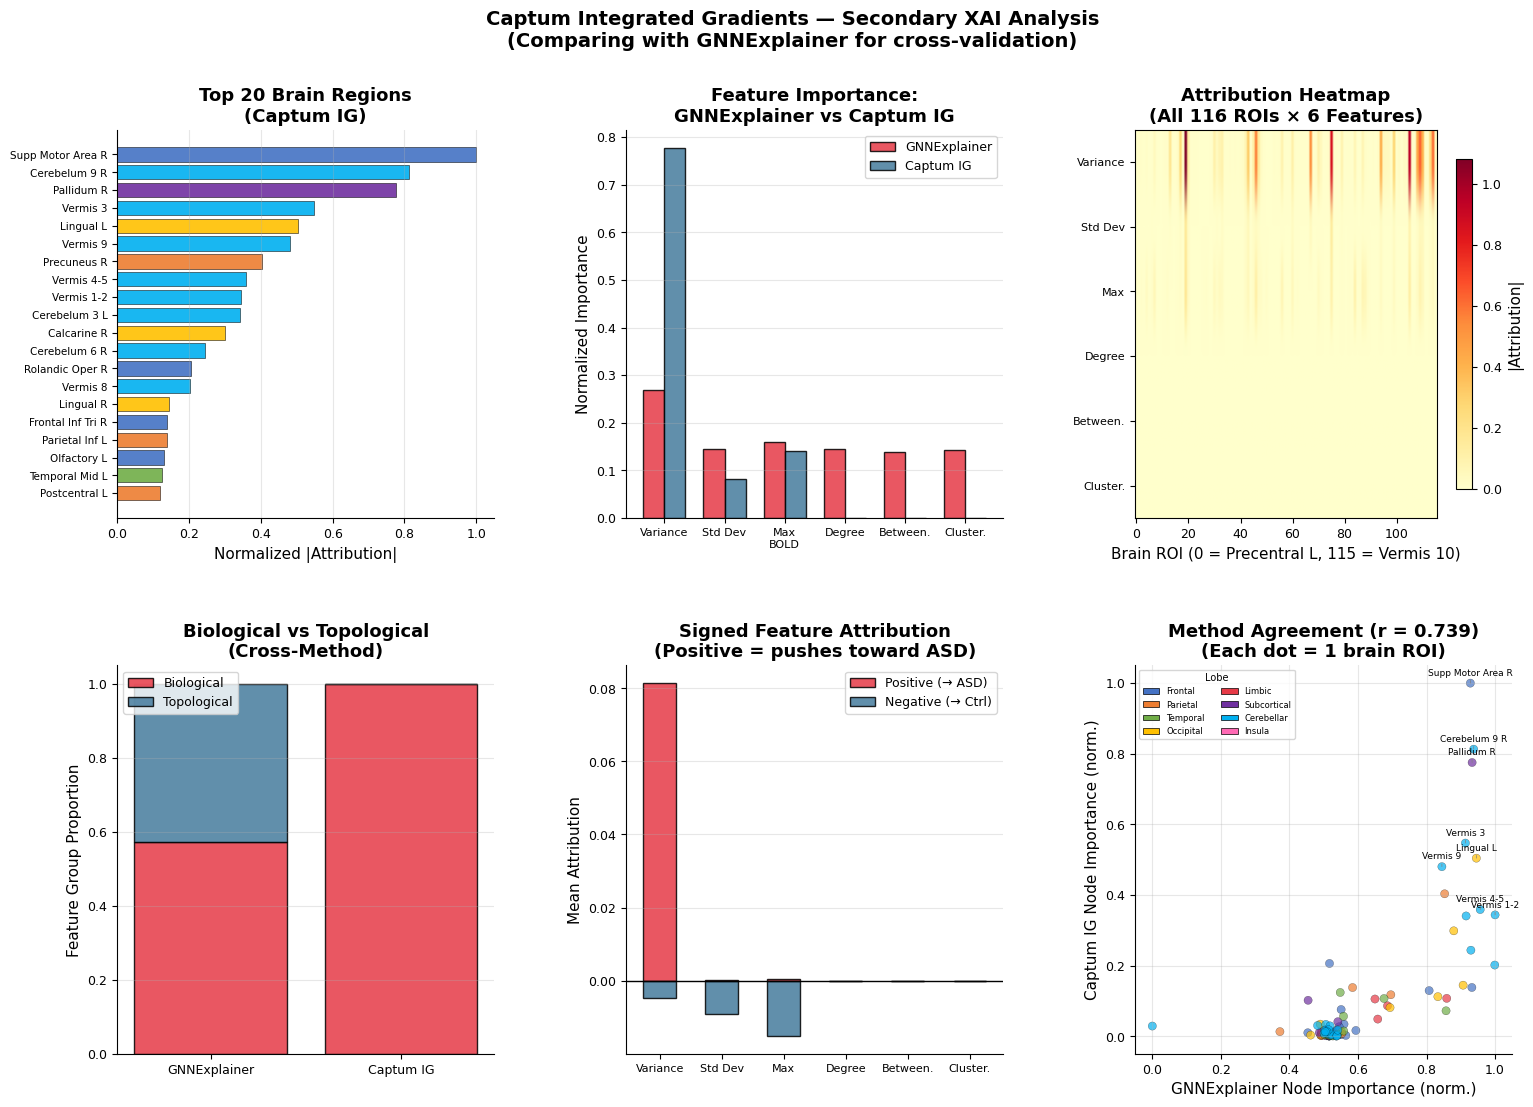

✅ Saved: /content/drive/MyDrive/ASD_GNN_Research2/results/figures/captum_integrated_gradients.png

📊 Cross-method node importance correlation (Pearson r): 0.7388
   → Strong agreement between GNNExplainer and Captum IG


In [16]:
# ─── CELL 16: Captum Visualization & Cross-Method Comparison ─────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)
fig.suptitle('Captum Integrated Gradients — Secondary XAI Analysis\n'
              '(Comparing with GNNExplainer for cross-validation)',
              fontsize=14, fontweight='bold')

# ── 1. Top 20 ROIs by IG attribution ──
ax1 = fig.add_subplot(gs[0, 0])
node_attr_total = np.abs(attr_np).sum(axis=1)  # [116]
top20_ig_idx    = node_attr_total.argsort()[::-1][:20]
top20_ig_names  = [AAL_REGIONS.get(i, f'R{i}') for i in top20_ig_idx]
top20_ig_scores = node_attr_total[top20_ig_idx]
top20_ig_colors = [get_lobe_color(i) for i in top20_ig_idx]

ax1.barh(range(20), top20_ig_scores[::-1] / top20_ig_scores.max(),
          color=top20_ig_colors[::-1], edgecolor='black', linewidth=0.4, alpha=0.9)
ax1.set_yticks(range(20))
ax1.set_yticklabels(top20_ig_names[::-1], fontsize=7.5)
ax1.set_xlabel('Normalized |Attribution|')
ax1.set_title('Top 20 Brain Regions\n(Captum IG)', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── 2. Feature comparison: GNNExplainer vs Captum IG ──
ax2 = fig.add_subplot(gs[0, 1])
x_pos = np.arange(len(FEATURE_NAMES))
w = 0.35
ax2.bar(x_pos - w/2, fi_norm, w, label='GNNExplainer',
         color='#E63946', alpha=0.85, edgecolor='black')
ax2.bar(x_pos + w/2, ig_feature_norm, w, label='Captum IG',
         color='#457B9D', alpha=0.85, edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Variance', 'Std Dev', 'Max\nBOLD',
                      'Degree', 'Between.', 'Cluster.'], fontsize=8)
ax2.set_ylabel('Normalized Importance')
ax2.set_title('Feature Importance:\nGNNExplainer vs Captum IG', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── 3. Full attribution heatmap [6 × 116] ──
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(np.abs(attr_np).T, cmap='YlOrRd', aspect='auto')
ax3.set_yticks(range(6))
ax3.set_yticklabels(['Variance', 'Std Dev', 'Max', 'Degree', 'Between.', 'Cluster.'], fontsize=8)
ax3.set_xlabel('Brain ROI (0 = Precentral L, 115 = Vermis 10)')
ax3.set_title('Attribution Heatmap\n(All 116 ROIs × 6 Features)', fontweight='bold')
plt.colorbar(im3, ax=ax3, shrink=0.85, label='|Attribution|')

# ── 4. Bio vs Topo stacked comparison ──
ax4 = fig.add_subplot(gs[1, 0])
bio_ig   = ig_feature_norm[:3].sum()
topo_ig  = ig_feature_norm[3:].sum()
methods  = ['GNNExplainer', 'Captum IG']
bio_vals = [bio_total, bio_ig]
top_vals = [topo_total, topo_ig]
ax4.bar(methods, bio_vals,  label='Biological',  color='#E63946', alpha=0.85, edgecolor='black')
ax4.bar(methods, top_vals,  bottom=bio_vals, label='Topological', color='#457B9D', alpha=0.85, edgecolor='black')
ax4.set_ylabel('Feature Group Proportion')
ax4.set_title('Biological vs Topological\n(Cross-Method)', fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── 5. Signed attribution: positive vs negative contributions ──
ax5 = fig.add_subplot(gs[1, 1])
pos_attr = attr_np.clip(min=0).mean(axis=0)  # positive attributions (push toward ASD)
neg_attr = attr_np.clip(max=0).mean(axis=0)  # negative attributions (push away from ASD)
ax5.bar(x_pos, pos_attr, w*1.5, label='Positive (→ ASD)',
         color='#E63946', alpha=0.85, edgecolor='black')
ax5.bar(x_pos, neg_attr, w*1.5, label='Negative (→ Ctrl)',
         color='#457B9D', alpha=0.85, edgecolor='black')
ax5.axhline(0, color='black', lw=1)
ax5.set_xticks(x_pos)
ax5.set_xticklabels(['Variance', 'Std Dev', 'Max', 'Degree', 'Between.', 'Cluster.'], fontsize=8)
ax5.set_ylabel('Mean Attribution')
ax5.set_title('Signed Feature Attribution\n(Positive = pushes toward ASD)', fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# ── 6. Correlation between GNNExplainer and IG node importance ──
ax6 = fig.add_subplot(gs[1, 2])
gnn_node_imp  = np.abs(node_masks).sum(axis=1)   # GNNExplainer per-node [116]
ig_node_imp   = node_attr_total                    # Captum IG per-node    [116]
gnn_node_norm = gnn_node_imp / (gnn_node_imp.max() + 1e-8)
ig_node_norm  = ig_node_imp  / (ig_node_imp.max()  + 1e-8)

scatter_colors = [get_lobe_color(i) for i in range(116)]
ax6.scatter(gnn_node_norm, ig_node_norm, c=scatter_colors,
             s=35, alpha=0.7, edgecolors='k', linewidth=0.2)

# Annotate top 8 nodes (highest average rank)
combined_rank = gnn_node_norm + ig_node_norm
top8 = combined_rank.argsort()[::-1][:8]
for n in top8:
    ax6.annotate(AAL_REGIONS.get(n, f'R{n}'),
                  (gnn_node_norm[n], ig_node_norm[n]),
                  fontsize=6.5, ha='center', va='bottom',
                  xytext=(0, 4), textcoords='offset points',
                  arrowprops=dict(arrowstyle='-', lw=0.5, color='gray'))

# Correlation coefficient
corr = np.corrcoef(gnn_node_norm, ig_node_norm)[0, 1]
ax6.set_xlabel('GNNExplainer Node Importance (norm.)')
ax6.set_ylabel('Captum IG Node Importance (norm.)')
ax6.set_title(f'Method Agreement (r = {corr:.3f})\n(Each dot = 1 brain ROI)', fontweight='bold')
ax6.grid(alpha=0.3)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

# Lobe legend (compact)
lp = [mpatches.Patch(facecolor=c, edgecolor='k', label=l, linewidth=0.5)
      for l, c in LOBE_COLORS.items()]
ax6.legend(handles=lp, fontsize=6, loc='upper left',
            title='Lobe', title_fontsize=7, ncol=2)

fig_path = os.path.join(FIGURES_DIR, 'captum_integrated_gradients.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fig_path}")
print(f"\n📊 Cross-method node importance correlation (Pearson r): {corr:.4f}")
if corr > 0.5:
    print("   → Strong agreement between GNNExplainer and Captum IG")
elif corr > 0.3:
    print("   → Moderate agreement between the two XAI methods")
else:
    print("   → Low agreement — methods capture different aspects of the model")

---
## 👁️ Section 8: GAT Attention Weight Visualization
> GAT (Graph Attention Network) learns to focus on different brain connections via learnable attention coefficients.
> This section extracts and visualizes these attention weights — a unique XAI property of GAT vs standard GCN.

In [17]:
# ─── CELL 17: Extract GAT Attention Weights ───────────────────────────────────
model.eval()

with torch.no_grad():
    alpha1, alpha2, ei_att = model.get_attention_weights(
        x_target, ei_target, edge_attr=ea_target
    )

alpha1_np = alpha1.cpu().numpy()  # [E, 4]  — Layer 1, 4 heads
alpha2_np = alpha2.cpu().numpy()  # [E, 1]  — Layer 2, 1 head
ei_np     = ei_att.cpu().numpy()  # [2, E]

print(f"Layer 1 attention: {alpha1_np.shape}  (edges × 4 heads)")
print(f"Layer 2 attention: {alpha2_np.shape}  (edges × 1 head)")

# Average across heads
avg_a1 = alpha1_np.mean(axis=1)   # [E]
avg_a2 = alpha2_np.squeeze(-1)    # [E]

N_NODES = target_data.x.size(0)   # 116

# Compute per-node attention received (sum of incoming attention)
att_recv_l1 = np.zeros(N_NODES)
att_recv_l2 = np.zeros(N_NODES)
for k in range(len(avg_a1)):
    t = ei_np[1, k]  # target node of edge k
    att_recv_l1[t] += avg_a1[k]
    att_recv_l2[t] += avg_a2[k]

att_recv_l1_norm = att_recv_l1 / (att_recv_l1.max() + 1e-8)
att_recv_l2_norm = att_recv_l2 / (att_recv_l2.max() + 1e-8)

print(f"\nTop 5 nodes by Layer-1 attention:")
for idx in att_recv_l1_norm.argsort()[::-1][:5]:
    print(f"  {AAL_REGIONS.get(idx, f'R{idx}'):<30} {att_recv_l1_norm[idx]:.4f}")

print(f"\nTop 5 nodes by Layer-2 attention:")
for idx in att_recv_l2_norm.argsort()[::-1][:5]:
    print(f"  {AAL_REGIONS.get(idx, f'R{idx}'):<30} {att_recv_l2_norm[idx]:.4f}")

Layer 1 attention: (3150, 4)  (edges × 4 heads)
Layer 2 attention: (3150, 1)  (edges × 1 head)

Top 5 nodes by Layer-1 attention:
  Temporal Mid R                 1.0000
  Frontal Sup Orb L              1.0000
  Cerebelum Crus1 R              1.0000
  Frontal Inf Orb R              1.0000
  Cerebelum 8 L                  1.0000

Top 5 nodes by Layer-2 attention:
  Paracentral Lob R              1.0000
  Cuneus L                       1.0000
  Cerebelum 9 R                  1.0000
  Cerebelum 4-5 R                1.0000
  Vermis 7                       1.0000


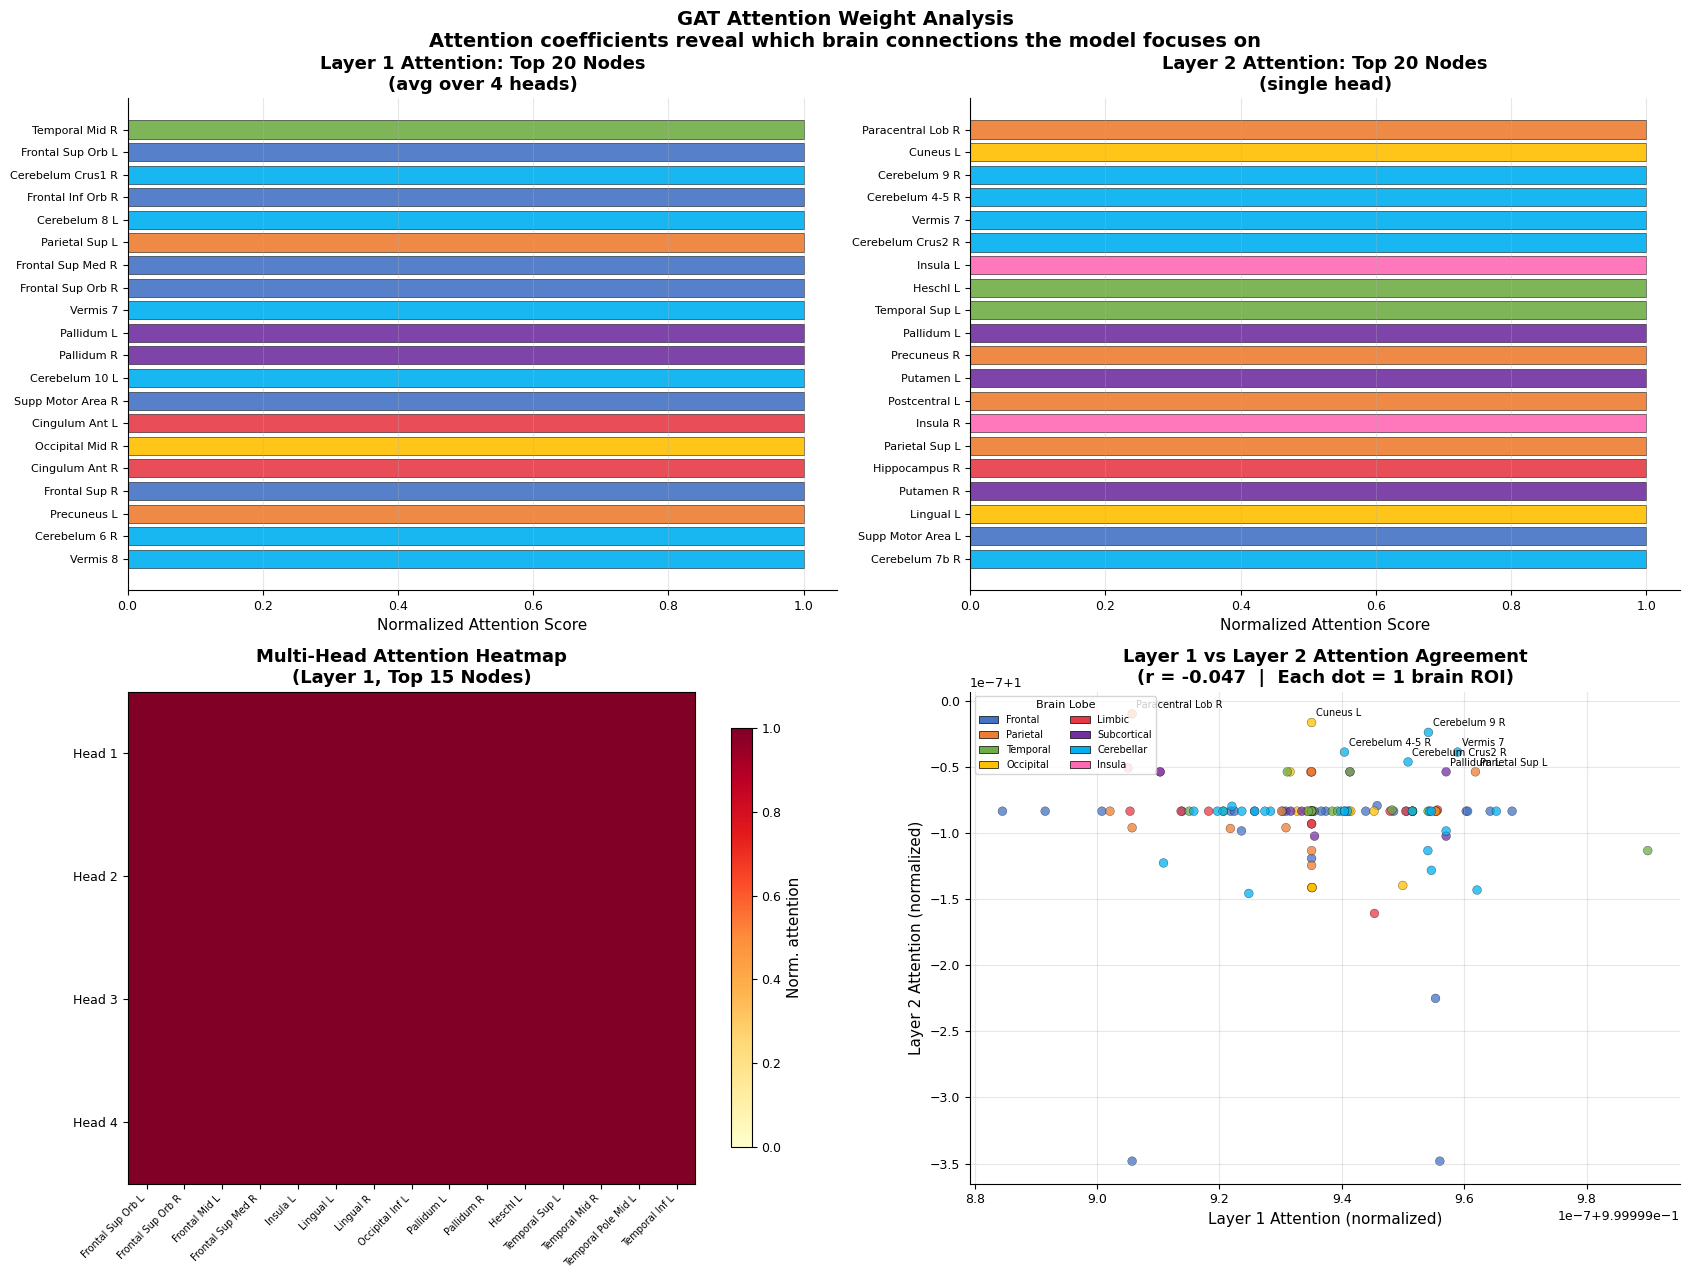

✅ Saved: /content/drive/MyDrive/ASD_GNN_Research2/results/figures/gat_attention_weights.png


In [18]:
# ─── CELL 18: GAT Attention Visualization ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(17, 13))
fig.suptitle('GAT Attention Weight Analysis\n'
              'Attention coefficients reveal which brain connections the model focuses on',
              fontsize=14, fontweight='bold')

# ── 1. Layer 1 — Top 20 most-attended nodes ──
ax1 = axes[0, 0]
top20_l1_idx    = att_recv_l1_norm.argsort()[::-1][:20]
top20_l1_scores = att_recv_l1_norm[top20_l1_idx]
top20_l1_names  = [AAL_REGIONS.get(i, f'R{i}') for i in top20_l1_idx]
top20_l1_colors = [get_lobe_color(i) for i in top20_l1_idx]

ax1.barh(range(20), top20_l1_scores[::-1], color=top20_l1_colors[::-1],
          edgecolor='black', linewidth=0.4, alpha=0.9)
ax1.set_yticks(range(20))
ax1.set_yticklabels(top20_l1_names[::-1], fontsize=8)
ax1.set_xlabel('Normalized Attention Score')
ax1.set_title('Layer 1 Attention: Top 20 Nodes\n(avg over 4 heads)', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── 2. Layer 2 — Top 20 most-attended nodes ──
ax2 = axes[0, 1]
top20_l2_idx    = att_recv_l2_norm.argsort()[::-1][:20]
top20_l2_scores = att_recv_l2_norm[top20_l2_idx]
top20_l2_names  = [AAL_REGIONS.get(i, f'R{i}') for i in top20_l2_idx]
top20_l2_colors = [get_lobe_color(i) for i in top20_l2_idx]

ax2.barh(range(20), top20_l2_scores[::-1], color=top20_l2_colors[::-1],
          edgecolor='black', linewidth=0.4, alpha=0.9)
ax2.set_yticks(range(20))
ax2.set_yticklabels(top20_l2_names[::-1], fontsize=8)
ax2.set_xlabel('Normalized Attention Score')
ax2.set_title('Layer 2 Attention: Top 20 Nodes\n(single head)', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── 3. Multi-head heatmap (Layer 1, 4 heads) ──
ax3 = axes[1, 0]
# Build per-head per-node attention
head_node_att = np.zeros((4, N_NODES))
for h in range(4):
    for k in range(alpha1_np.shape[0]):
        head_node_att[h, ei_np[1, k]] += alpha1_np[k, h]
head_node_norm = head_node_att / (head_node_att.max(axis=1, keepdims=True) + 1e-8)

# Select top-15 nodes across all heads
head_top_nodes = np.unique(
    np.concatenate([head_node_norm[h].argsort()[::-1][:8] for h in range(4)])
)[:15]
hm_data   = head_node_norm[:, head_top_nodes]
hm_labels = [AAL_REGIONS.get(n, f'R{n}') for n in head_top_nodes]

im3 = ax3.imshow(hm_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(len(head_top_nodes)))
ax3.set_xticklabels(hm_labels, rotation=45, ha='right', fontsize=7)
ax3.set_yticks(range(4))
ax3.set_yticklabels([f'Head {i+1}' for i in range(4)], fontsize=9)
ax3.set_title('Multi-Head Attention Heatmap\n(Layer 1, Top 15 Nodes)', fontweight='bold')
plt.colorbar(im3, ax=ax3, shrink=0.85, label='Norm. attention')

# ── 4. Layer1 vs Layer2 attention scatter ──
ax4 = axes[1, 1]
sc4 = ax4.scatter(
    att_recv_l1_norm, att_recv_l2_norm,
    c=[get_lobe_color(i) for i in range(N_NODES)],
    s=40, alpha=0.75, edgecolors='k', linewidth=0.25
)
# Annotate top 8
top8_both = (att_recv_l1_norm + att_recv_l2_norm).argsort()[::-1][:8]
for n in top8_both:
    ax4.annotate(
        AAL_REGIONS.get(n, f'R{n}'),
        (att_recv_l1_norm[n], att_recv_l2_norm[n]),
        fontsize=7, ha='left', va='bottom',
        xytext=(3, 3), textcoords='offset points'
    )

att_corr = np.corrcoef(att_recv_l1_norm, att_recv_l2_norm)[0, 1]
ax4.set_xlabel('Layer 1 Attention (normalized)')
ax4.set_ylabel('Layer 2 Attention (normalized)')
ax4.set_title(f'Layer 1 vs Layer 2 Attention Agreement\n(r = {att_corr:.3f}  |  Each dot = 1 brain ROI)',
               fontweight='bold')
ax4.grid(alpha=0.3)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

lp4 = [mpatches.Patch(facecolor=c, edgecolor='k', linewidth=0.5, label=l)
        for l, c in LOBE_COLORS.items()]
ax4.legend(handles=lp4, fontsize=7, loc='upper left',
            title='Brain Lobe', title_fontsize=8, ncol=2)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'gat_attention_weights.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fig_path}")

---
## 📋 Section 9: Comprehensive Summary Report

In [19]:
# ─── CELL 19: Final Summary Report ────────────────────────────────────────────
n_params = sum(p.numel() for p in model.parameters())

print("=" * 68)
print("   FINAL RESEARCH SUMMARY REPORT")
print("   Explainable GNNs for ASD Classification — ABIDE I Dataset")
print("=" * 68)

print("\n📦 DATASET")
print(f"   Source:         ABIDE I (cpac pipeline, quality_checked=True)")
print(f"   Atlas:          AAL (116 regions of interest)")
print(f"   Total subjects: {total}")
print(f"   ASD:            {n_asd} ({100*n_asd/total:.1f}%)")
print(f"   Control:        {n_control} ({100*n_control/total:.1f}%)")
print(f"   Train/Val/Test: 609 / 131 / 131")

print("\n🏗️  MODEL")
print(f"   Architecture:   Graph Attention Network (GAT)")
print(f"   Layer 1:        GATConv(6→64, 4 heads, concat) → ELU → Dropout(0.4)")
print(f"   Layer 2:        GATConv(256→64, 1 head) → ELU → GlobalMeanPool")
print(f"   Classifier:     Linear(64→32) → ELU → Linear(32→2)")
print(f"   Parameters:     {n_params:,}")
print(f"   Node features:  6 [BOLD variance, std, max | degree, betweenness, clustering]")
print(f"   Edge features:  Pearson correlation weight (threshold > 0.3)")

print("\n📈 PERFORMANCE (Test Set, N=131)")
print(f"   Accuracy:       {acc:.4f}  ({acc*100:.2f}%)")
print(f"   Weighted F1:    {f1:.4f}")
print(f"   AUC-ROC:        {auc:.4f}")
print(f"   Sensitivity:    {sensitivity:.4f}  ({sensitivity*100:.2f}%)   [ASD recall]")
print(f"   Specificity:    {specificity:.4f}  ({specificity*100:.2f}%)   [Control recall]")

print("\n🔬 XAI METHODS")
print(f"   1. GNNExplainer (Primary):")
print(f"      - Edge importance masks (top biomarker connections)")
print(f"      - Node importance masks (feature attribution per ROI)")
print(f"      - Top hub region: {AAL_REGIONS.get(sorted_edges[0][0][0], 'N/A')} ↔ {AAL_REGIONS.get(sorted_edges[0][0][1], 'N/A')}")
print(f"   2. Captum Integrated Gradients (Secondary):")
print(f"      - Node-level feature attribution")
print(f"      - Convergence delta: {delta_val:.6f}")
print(f"      - Cross-method agreement (r = {corr:.3f})")
print(f"   3. GAT Attention Weights:")
print(f"      - Layer 1 (4-head) + Layer 2 (1-head) attention analysis")
print(f"      - L1–L2 agreement: r = {att_corr:.3f}")

print("\n📁 FILES GENERATED")
files_generated = [
    ('Figures', [
        'class_distribution.png',
        'confusion_matrix_roc.png',
        'biomarker_network_gnnexplainer.png',
        'feature_importance_gnnexplainer.png',
        'captum_integrated_gradients.png',
        'gat_attention_weights.png',
    ]),
    ('Metrics', [
        'evaluation_metrics.csv',
        'gnnexplainer_biomarkers.csv',
    ])
]
for folder, flist in files_generated:
    print(f"   [{folder}]")
    for f in flist:
        print(f"   ✅  results/{folder.lower()}/{f}")

print("\n" + "=" * 68)
print("   Notebook 06 complete. All files saved to Google Drive.")
print("=" * 68)

   FINAL RESEARCH SUMMARY REPORT
   Explainable GNNs for ASD Classification — ABIDE I Dataset

📦 DATASET
   Source:         ABIDE I (cpac pipeline, quality_checked=True)
   Atlas:          AAL (116 regions of interest)
   Total subjects: 871
   ASD:            403 (46.3%)
   Control:        468 (53.7%)
   Train/Val/Test: 609 / 131 / 131

🏗️  MODEL
   Architecture:   Graph Attention Network (GAT)
   Layer 1:        GATConv(6→64, 4 heads, concat) → ELU → Dropout(0.4)
   Layer 2:        GATConv(256→64, 1 head) → ELU → GlobalMeanPool
   Classifier:     Linear(64→32) → ELU → Linear(32→2)
   Parameters:     21,026
   Node features:  6 [BOLD variance, std, max | degree, betweenness, clustering]
   Edge features:  Pearson correlation weight (threshold > 0.3)

📈 PERFORMANCE (Test Set, N=131)
   Accuracy:       0.5420  (54.20%)
   Weighted F1:    0.3891
   AUC-ROC:        0.4665
   Sensitivity:    0.0164  (1.64%)   [ASD recall]
   Specificity:    1.0000  (100.00%)   [Control recall]

🔬 XAI METHO